In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
    MinMaxScaler,
    RobustScaler
)
from sklearn.feature_selection import SelectKBest, f_classif

In [2]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["Species"] = iris.target

species_map = {
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
}

df["Species"] = df["Species"].map(species_map)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [3]:
np.random.seed(42)

sizes = ["Small", "Medium", "Large"]

df["Plant_Size"] = np.random.choice(sizes, len(df))

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species,Plant_Size
0,5.1,3.5,1.4,0.2,Setosa,Large
1,4.9,3.0,1.4,0.2,Setosa,Small
2,4.7,3.2,1.3,0.2,Setosa,Large
3,4.6,3.1,1.5,0.2,Setosa,Large
4,5.0,3.6,1.4,0.2,Setosa,Small


In [4]:
label_encoder = LabelEncoder()

df["Species_Label"] = label_encoder.fit_transform(df["Species"])

df[["Species", "Species_Label"]].head()

,Species,Species_Label
0,Setosa,0
1,Setosa,0
2,Setosa,0
3,Setosa,0
4,Setosa,0


In [5]:
onehot = OneHotEncoder(sparse_output=False)

encoded = onehot.fit_transform(df[["Species"]])

encoded_df = pd.DataFrame(
    encoded,
    columns=onehot.get_feature_names_out(["Species"])
)

encoded_df.head()

,Species_Setosa,Species_Versicolor,Species_Virginica
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,1.0,0.0,0.0
3,1.0,0.0,0.0
4,1.0,0.0,0.0


In [6]:
ordinal = OrdinalEncoder(
    categories=[["Small", "Medium", "Large"]]
)

df["Plant_Size_Encoded"] = ordinal.fit_transform(
    df[["Plant_Size"]]
)

df[["Plant_Size", "Plant_Size_Encoded"]].head()

,Plant_Size,Plant_Size_Encoded
0,Large,2.0
1,Small,0.0
2,Large,2.0
3,Large,2.0
4,Small,0.0


In [7]:
standard = StandardScaler()

standard_scaled = standard.fit_transform(iris.data)

standard_df = pd.DataFrame(
    standard_scaled,
    columns=iris.feature_names
)

standard_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


In [8]:
minmax = MinMaxScaler()

minmax_scaled = minmax.fit_transform(iris.data)

minmax_df = pd.DataFrame(
    minmax_scaled,
    columns=iris.feature_names
)

minmax_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,0.222222,0.625000,0.067797,0.041667
1,0.166667,0.416667,0.067797,0.041667
2,0.111111,0.500000,0.050847,0.041667
3,0.083333,0.458333,0.084746,0.041667
4,0.194444,0.666667,0.067797,0.041667


In [9]:
robust = RobustScaler()

robust_scaled = robust.fit_transform(iris.data)

robust_df = pd.DataFrame(
    robust_scaled,
    columns=iris.feature_names
)

robust_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.538462,1.0,-0.842857,-0.733333
1,-0.692308,0.0,-0.842857,-0.733333
2,-0.846154,0.4,-0.871429,-0.733333
3,-0.923077,0.2,-0.814286,-0.733333
4,-0.615385,1.2,-0.842857,-0.733333


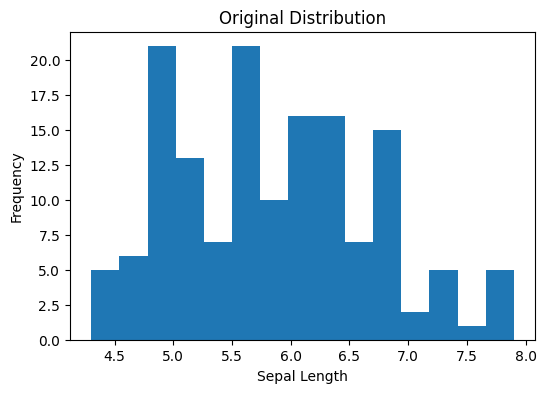

In [10]:
plt.figure(figsize=(6,4))
plt.hist(df["sepal length (cm)"], bins=15)
plt.title("Original Distribution")
plt.xlabel("Sepal Length")
plt.ylabel("Frequency")
plt.show()

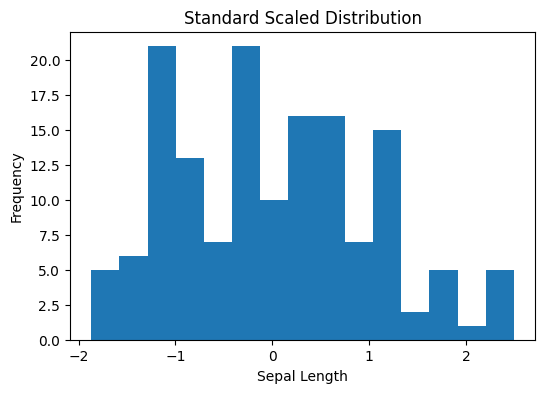

In [11]:
plt.figure(figsize=(6,4))
plt.hist(standard_df["sepal length (cm)"], bins=15)
plt.title("Standard Scaled Distribution")
plt.xlabel("Sepal Length")
plt.ylabel("Frequency")
plt.show()

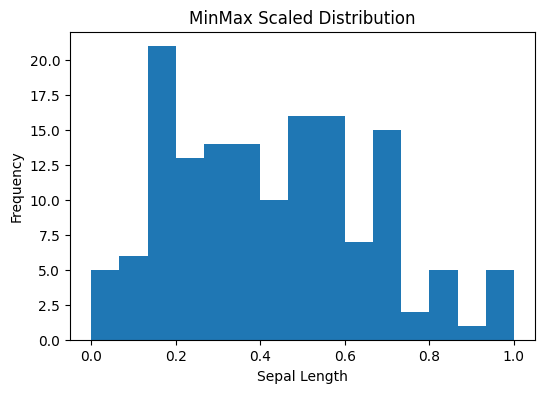

In [12]:
plt.figure(figsize=(6,4))
plt.hist(minmax_df["sepal length (cm)"], bins=15)
plt.title("MinMax Scaled Distribution")
plt.xlabel("Sepal Length")
plt.ylabel("Frequency")
plt.show()

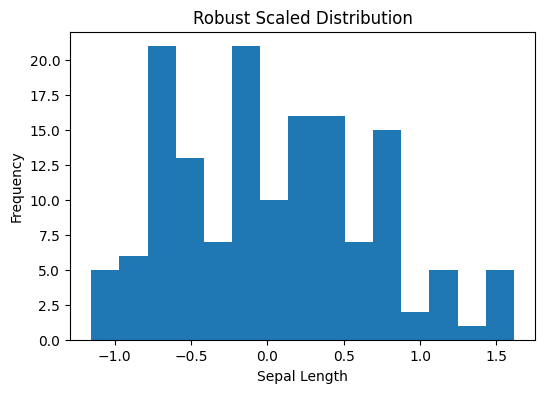

In [13]:
plt.figure(figsize=(6,4))
plt.hist(robust_df["sepal length (cm)"], bins=15)
plt.title("Robust Scaled Distribution")
plt.xlabel("Sepal Length")
plt.ylabel("Frequency")
plt.show()

In [14]:
X = iris.data
y = iris.target

selector = SelectKBest(score_func=f_classif, k=4)

selector.fit(X, y)

scores = pd.DataFrame({
    "Feature": iris.feature_names,
    "Score": selector.scores_
})

scores = scores.sort_values(by="Score", ascending=False)

scores

,Feature,Score
2,petal length (cm),1180.161182
3,petal width (cm),960.007147
0,sepal length (cm),119.264502
1,sepal width (cm),49.160040


In [20]:
selected_features = scores["Feature"].tolist()

print("Selected Features:")

for feature in selected_features:
    print(feature)

Selected Features:
petal length (cm)
petal width (cm)
sepal length (cm)
sepal width (cm)


In [21]:
print("LabelEncoder:")
print("- Converts categories into numbers.")
print("- Suitable for target labels.")
print("- Not ideal for unordered categorical features.\n")

print("OneHotEncoder:")
print("- Creates binary columns.")
print("- Best for nominal categories.")
print("- Can increase dataset size.\n")

print("OrdinalEncoder:")
print("- Used when categories have a natural order.")
print("- Preserves ranking information.")

LabelEncoder:
- Converts categories into numbers.
- Suitable for target labels.
- Not ideal for unordered categorical features.

OneHotEncoder:
- Creates binary columns.
- Best for nominal categories.
- Can increase dataset size.

OrdinalEncoder:
- Used when categories have a natural order.
- Preserves ranking information.


In [22]:
print("StandardScaler:")
print("- Centers data around mean 0 with standard deviation 1.\n")

print("MinMaxScaler:")
print("- Scales values between 0 and 1.\n")

print("RobustScaler:")
print("- Uses median and IQR.")
print("- Performs well with outliers.")


StandardScaler:
- Centers data around mean 0 with standard deviation 1.

MinMaxScaler:
- Scales values between 0 and 1.

RobustScaler:
- Uses median and IQR.
- Performs well with outliers.


In [23]:
feature_explanations = {
    "petal length (cm)": "Strong indicator for distinguishing flower species.",
    "petal width (cm)": "Highly correlated with species classification.",
    "sepal length (cm)": "Useful for separating species, though less than petal features.",
    "sepal width (cm)": "Provides additional information for classification."
}

for feature, explanation in feature_explanations.items():
    print(f"{feature}: {explanation}")

petal length (cm): Strong indicator for distinguishing flower species.
petal width (cm): Highly correlated with species classification.
sepal length (cm): Useful for separating species, though less than petal features.
sepal width (cm): Provides additional information for classification.


In [24]:
checklist = [
    "LabelEncoder applied",
    "OneHotEncoder applied",
    "OrdinalEncoder applied",
    "StandardScaler applied",
    "MinMaxScaler applied",
    "RobustScaler applied",
    "Distribution plots generated",
    "SelectKBest applied",
    "Feature importance documented",
    "Notebook executed successfully"
]

print("Self-Review Checklist:\n")

for item in checklist:
    print(f"✅ {item}")

Self-Review Checklist:

✅ LabelEncoder applied
✅ OneHotEncoder applied
✅ OrdinalEncoder applied
✅ StandardScaler applied
✅ MinMaxScaler applied
✅ RobustScaler applied
✅ Distribution plots generated
✅ SelectKBest applied
✅ Feature importance documented
✅ Notebook executed successfully


In [25]:
checklist = [
    "LabelEncoder applied",
    "OneHotEncoder applied",
    "OrdinalEncoder applied",
    "StandardScaler applied",
    "MinMaxScaler applied",
    "RobustScaler applied",
    "Distribution plots generated",
    "SelectKBest applied",
    "Feature importance documented",
    "Notebook executed successfully"
]

print("Self-Review Checklist:\n")

for item in checklist:
    print(f"✅ {item}")

Self-Review Checklist:

✅ LabelEncoder applied
✅ OneHotEncoder applied
✅ OrdinalEncoder applied
✅ StandardScaler applied
✅ MinMaxScaler applied
✅ RobustScaler applied
✅ Distribution plots generated
✅ SelectKBest applied
✅ Feature importance documented
✅ Notebook executed successfully
